# Análisis Estratégico de la Diversificación de la Matriz Energética en Colombia (2020-2026)

## Retos y Oportunidades: Integración de Fuentes No Convencionales de Energía Renovable (FNCER) vs. Generación Hidráulica

**Autor:** [GRUPO H]  
**Materia:** Análisis de Datos Avanzado   
**Fuente de Datos:** Modelo de Datos Sintéticos (Basado en tendencias de XM, UPME, SGC).

**Alineación con el repositorio:** el script SQL en `database/` carga una muestra distinta (generación diaria **2020-01-01** a **2020-05-21**; costos con corte **2024**). Este cuaderno conserva el horizonte **2020–2026** únicamente sobre la serie **sintética** del análisis.


## Alcance del análisis

Este cuaderno examina la evolución comparada de cuatro tecnologías de generación energética en el periodo 2020–2026:

- Solar
- Eólica
- Geotérmica
- Hídrica

El objetivo es evaluar patrones de cambio en generación, costo, emisiones, participación relativa y diversificación de la matriz, con una lectura orientada a toma de decisiones, discusión técnica y evaluación estratégica del proceso de transición energética.

El análisis se estructura en cinco planos complementarios:

1. **Escala y trayectoria de generación**
2. **Competitividad económica relativa**
3. **Desempeño ambiental**
4. **Cambios en la composición de la matriz**
5. **Balance entre expansión, costo y sostenibilidad**

La lógica metodológica combina validación de datos, construcción de indicadores derivados, agregación analítica por año y tecnología, y visualización multivariable para identificar tendencias, trade-offs y señales estructurales del sistema.


## 1. Librerías y configuración visual

Se cargan las librerías requeridas para procesamiento de datos, modelación tabular, construcción de indicadores y visualización analítica. La configuración gráfica prioriza legibilidad, consistencia y comparabilidad entre tecnologías.


In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Construcción del dataset de trabajo

Se define la base de análisis para el periodo 2020–2026, incorporando las variables necesarias para examinar generación, demanda, cobertura, costos, inversión y emisiones por tecnología. La estructura del conjunto permite comparar trayectorias tecnológicas y construir una lectura integrada del sistema.


In [2]:
# Parámetros base de la simulación
num_records = 1000
years = range(2020, 2027)  # Incluye 2026
energy_types = ['Solar', 'Eólica', 'Geotérmica', 'Hídrica']

# Semillas para reproducibilidad
random.seed(42)
np.random.seed(42)

# Lista contenedora
data_records = []

# Tendencias por tecnología y métrica
trends = {
    'Solar': {
        'Generacion_GWh': {'start': 1, 'end': 60, 'min_var': 0.8, 'max_var': 1.2},
        'Oferta_GWh': {'start': 1.2, 'end': 65, 'min_var': 0.9, 'max_var': 1.1},
        'Demanda_GWh': {'start': 0.8, 'end': 55, 'min_var': 0.9, 'max_var': 1.0},
        'Costo_MWh': {'start': 50, 'end': 30, 'min_var': 0.9, 'max_var': 1.1},
        'Porcentaje_Cobertura': {'start': 0.01, 'end': 0.15, 'min_var': 0.8, 'max_var': 1.2},
        'Inversion_USD_millones': {'start': 100, 'end': 500, 'min_var': 0.8, 'max_var': 1.2},
        'Emisiones_CO2_toneladas': {'start': 5, 'end': 10, 'min_var': 0.8, 'max_var': 1.2}
    },
    'Eólica': {
        'Generacion_GWh': {'start': 0.5, 'end': 40, 'min_var': 0.8, 'max_var': 1.2},
        'Oferta_GWh': {'start': 0.6, 'end': 45, 'min_var': 0.9, 'max_var': 1.1},
        'Demanda_GWh': {'start': 0.4, 'end': 38, 'min_var': 0.9, 'max_var': 1.0},
        'Costo_MWh': {'start': 60, 'end': 40, 'min_var': 0.9, 'max_var': 1.1},
        'Porcentaje_Cobertura': {'start': 0.005, 'end': 0.1, 'min_var': 0.8, 'max_var': 1.2},
        'Inversion_USD_millones': {'start': 80, 'end': 400, 'min_var': 0.8, 'max_var': 1.2},
        'Emisiones_CO2_toneladas': {'start': 3, 'end': 8, 'min_var': 0.8, 'max_var': 1.2}
    },
    'Geotérmica': {
        'Generacion_GWh': {'start': 0, 'end': 5, 'min_var': 0.8, 'max_var': 1.2},
        'Oferta_GWh': {'start': 0, 'end': 6, 'min_var': 0.9, 'max_var': 1.1},
        'Demanda_GWh': {'start': 0, 'end': 4, 'min_var': 0.9, 'max_var': 1.0},
        'Costo_MWh': {'start': 70, 'end': 50, 'min_var': 0.9, 'max_var': 1.1},
        'Porcentaje_Cobertura': {'start': 0, 'end': 0.02, 'min_var': 0.8, 'max_var': 1.2},
        'Inversion_USD_millones': {'start': 50, 'end': 200, 'min_var': 0.8, 'max_var': 1.2},
        'Emisiones_CO2_toneladas': {'start': 10, 'end': 20, 'min_var': 0.8, 'max_var': 1.2}
    },
    'Hídrica': {
        'Generacion_GWh': {'start': 120, 'end': 100, 'min_var': 0.8, 'max_var': 1.2},
        'Oferta_GWh': {'start': 125, 'end': 105, 'min_var': 0.9, 'max_var': 1.1},
        'Demanda_GWh': {'start': 110, 'end': 95, 'min_var': 0.9, 'max_var': 1.0},
        'Costo_MWh': {'start': 20, 'end': 25, 'min_var': 0.9, 'max_var': 1.1},
        'Porcentaje_Cobertura': {'start': 0.7, 'end': 0.5, 'min_var': 0.8, 'max_var': 1.2},
        'Inversion_USD_millones': {'start': 10, 'end': 50, 'min_var': 0.8, 'max_var': 1.2},
        'Emisiones_CO2_toneladas': {'start': 50, 'end': 60, 'min_var': 0.8, 'max_var': 1.2}
    }
}

def linear_interpolate(start_val, end_val, current_year, start_year=2020, end_year=2026):
    if start_year == end_year:
        return start_val
    progress = (current_year - start_year) / (end_year - start_year)
    return start_val + progress * (end_val - start_val)

for _ in range(num_records):
    year = random.choice(list(years))
    energy_type = random.choice(energy_types)

    record = {'Año': year, 'Tipo_Energia': energy_type}

    for metric, props in trends[energy_type].items():
        base_value = linear_interpolate(props['start'], props['end'], year)
        value = base_value * random.uniform(props['min_var'], props['max_var'])

        if metric not in ['Costo_MWh', 'Porcentaje_Cobertura']:
            value = max(0, value)

        record[metric] = value

    # Restricciones lógicas del modelo sintético
    record['Oferta_GWh'] = max(record['Oferta_GWh'], record['Generacion_GWh'] * 1.05)
    record['Demanda_GWh'] = min(record['Demanda_GWh'], record['Oferta_GWh'] * random.uniform(0.8, 0.95))
    record['Porcentaje_Cobertura'] = np.clip(record['Porcentaje_Cobertura'], 0.0, 1.0)
    record['Costo_MWh'] = max(0, record['Costo_MWh'])
    record['Inversion_USD_millones'] = max(0, record['Inversion_USD_millones'])
    record['Emisiones_CO2_toneladas'] = max(0, record['Emisiones_CO2_toneladas'])

    data_records.append(record)

df_synthetic = pd.DataFrame(data_records)

# Guardado para reutilización en otras consultas
df_synthetic.to_csv("datos_energeticos_sinteticos.csv", index=False)

display(df_synthetic.head())
print(f"Dimensión del dataset: {df_synthetic.shape}")
print("Archivo exportado: datos_energeticos_sinteticos.csv")

,Año,Tipo_Energia,Generacion_GWh,Oferta_GWh,Demanda_GWh,Costo_MWh,Porcentaje_Cobertura,Inversion_USD_millones,Emisiones_CO2_toneladas
0,2025,Solar,40.635216,51.920485,42.396025,34.909808,0.135619,501.311125,7.652109
1,2020,Solar,0.887455,1.201285,0.722123,46.988377,0.010600,101.797659,4.440881
2,2026,Solar,66.211377,69.521946,51.824379,28.667228,0.132919,552.698826,8.408841
3,2022,Geotérmica,1.735817,2.122851,1.297298,63.792222,0.007928,95.141375,13.610883
4,2024,Geotérmica,3.436470,4.163657,2.412220,53.582847,0.012210,124.787519,14.885273


Dimensión del dataset: (1000, 9)
Archivo exportado: datos_energeticos_sinteticos.csv


## 3. Revisión inicial y control de consistencia

Antes de interpretar resultados, se verifica la integridad del conjunto de datos en términos de estructura, tipología de variables, valores faltantes, rangos y relaciones lógicas entre magnitudes. Este control es indispensable para evitar inferencias distorsionadas y asegurar trazabilidad analítica.


In [3]:
print("Información general")
df_synthetic.info()

print("\nValores nulos por columna")
display(df_synthetic.isna().sum().to_frame("Nulos"))

print("\nResumen estadístico")
display(df_synthetic.describe(include="all").T)

# Validaciones lógicas
validaciones = {
    "Oferta >= Generación": (df_synthetic["Oferta_GWh"] >= df_synthetic["Generacion_GWh"]).all(),
    "Demanda <= Oferta": (df_synthetic["Demanda_GWh"] <= df_synthetic["Oferta_GWh"]).all(),
    "Cobertura entre 0 y 1": df_synthetic["Porcentaje_Cobertura"].between(0, 1).all(),
    "Costo no negativo": (df_synthetic["Costo_MWh"] >= 0).all(),
    "Inversión no negativa": (df_synthetic["Inversion_USD_millones"] >= 0).all(),
    "Emisiones no negativas": (df_synthetic["Emisiones_CO2_toneladas"] >= 0).all()
}

display(pd.DataFrame.from_dict(validaciones, orient="index", columns=["Cumple"]))

Información general
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Año                      1000 non-null   int64  
 1   Tipo_Energia             1000 non-null   object 
 2   Generacion_GWh           1000 non-null   float64
 3   Oferta_GWh               1000 non-null   float64
 4   Demanda_GWh              1000 non-null   float64
 5   Costo_MWh                1000 non-null   float64
 6   Porcentaje_Cobertura     1000 non-null   float64
 7   Inversion_USD_millones   1000 non-null   float64
 8   Emisiones_CO2_toneladas  1000 non-null   float64
dtypes: float64(7), int64(1), object(1)
memory usage: 70.4+ KB

Valores nulos por columna


,Nulos
Año,0
Tipo_Energia,0
Generacion_GWh,0
Oferta_GWh,0
Demanda_GWh,0
Costo_MWh,0
Porcentaje_Cobertura,0
Inversion_USD_millones,0
Emisiones_CO2_toneladas,0



Resumen estadístico


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Año,1000.0,NaN,NaN,NaN,2023.079,2.013657,2020.0,2021.0,2023.0,2025.0,2026.0
Tipo_Energia,1000,4,Solar,259,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Generacion_GWh,1000.0,NaN,NaN,NaN,41.465097,43.181201,0.0,3.678441,26.98448,71.372397,143.699289
Oferta_GWh,1000.0,NaN,NaN,NaN,46.248329,47.28074,0.0,4.343463,31.254038,74.941017,150.884253
Demanda_GWh,1000.0,NaN,NaN,NaN,36.236565,37.390644,0.0,2.64178,24.548977,54.950136,109.893457
Costo_MWh,1000.0,NaN,NaN,NaN,42.729285,15.076454,18.033855,27.217243,44.113708,54.283978,76.542151
Porcentaje_Cobertura,1000.0,NaN,NaN,NaN,0.185983,0.244287,0.0,0.014339,0.071844,0.179783,0.834919
Inversion_USD_millones,1000.0,NaN,NaN,NaN,180.502345,145.330406,8.149865,50.12221,143.214439,279.734685,584.294176
Emisiones_CO2_toneladas,1000.0,NaN,NaN,NaN,20.65918,20.400892,2.484531,6.519305,10.132775,23.58289,69.96345


,Cumple
Oferta >= Generación,True
Demanda <= Oferta,True
Cobertura entre 0 y 1,True
Costo no negativo,True
Inversión no negativa,True
Emisiones no negativas,True


## 4. Construcción de la base analítica por año y tecnología

La unidad de observación original se consolida en una base comparativa por **año** y **tipo de energía**, con el fin de capturar señales estructurales y reducir ruido observacional. Esta agregación permite analizar tendencias, diferenciales de desempeño y cambios en la composición de la matriz con mayor estabilidad.


In [17]:
df_comparativo = (
    df_synthetic
    .groupby(['Año', 'Tipo_Energia'], as_index=False)
    .agg({
        'Generacion_GWh': 'mean',
        'Oferta_GWh': 'mean',
        'Demanda_GWh': 'mean',
        'Costo_MWh': 'mean',
        'Porcentaje_Cobertura': 'mean',
        'Inversion_USD_millones': 'mean',
        'Emisiones_CO2_toneladas': 'mean'
    })
    .sort_values(['Tipo_Energia', 'Año'])
)

display(df_comparativo.head(10))

,Año,Tipo_Energia,Generacion_GWh,Oferta_GWh,Demanda_GWh,Costo_MWh,Porcentaje_Cobertura,Inversion_USD_millones,Emisiones_CO2_toneladas
0,2020,Eólica,0.503479,0.607312,0.377824,60.426474,0.004942,81.425324,3.081511
4,2021,Eólica,7.084080,8.180747,6.414730,56.611498,0.019973,137.136477,3.661594
8,2022,Eólica,13.064448,15.459357,12.261454,52.866008,0.036571,186.452851,4.581525
12,2023,Eólica,20.061491,23.088255,18.261077,49.601292,0.050673,244.146601,5.592550
16,2024,Eólica,26.763465,30.578327,24.048515,47.334538,0.071303,288.297081,6.136256
20,2025,Eólica,33.418608,38.411584,30.161570,43.195946,0.085734,356.906270,7.041333
24,2026,Eólica,40.542625,45.627592,35.920252,40.471430,0.102177,403.469898,8.135183
1,2020,Geotérmica,0.000000,0.000000,0.000000,69.668211,0.000000,50.104268,10.471252
5,2021,Geotérmica,0.833866,1.007848,0.636728,67.302713,0.003429,76.575473,11.683755
9,2022,Geotérmica,1.672966,2.009158,1.270067,63.191821,0.006804,98.445974,13.141759


## 5. Ingeniería de variables

Se construyen indicadores derivados para ampliar la capacidad explicativa del análisis:

- **Participación relativa** en la generación total
- **Crecimiento interanual**
- **Variación absoluta de generación**
- **Costo por unidad generada**
- **Intensidad de emisiones**
- **Índice de ecoeficiencia**
- **Emisiones evitadas frente a una referencia**
- **Índice de diversificación** de la matriz

Estos indicadores permiten examinar la transición energética no solo como expansión de oferta, sino como reconfiguración simultánea de escala, estructura de costos, desempeño ambiental y concentración tecnológica.


In [5]:
# Participación anual de generación
total_generacion_anual = df_comparativo.groupby("Año")["Generacion_GWh"].transform("sum")
df_comparativo["Participacion_Generacion_pct"] = (df_comparativo["Generacion_GWh"] / total_generacion_anual) * 100

# Crecimiento interanual y variación absoluta por tecnología
df_comparativo["Crecimiento_Generacion_pct"] = (
    df_comparativo.groupby("Tipo_Energia")["Generacion_GWh"].pct_change() * 100
)
df_comparativo["Variacion_Generacion_GWh"] = (
    df_comparativo.groupby("Tipo_Energia")["Generacion_GWh"].diff()
)

# Indicadores de eficiencia relativa
df_comparativo["Costo_por_GWh"] = df_comparativo["Costo_MWh"] / df_comparativo["Generacion_GWh"].replace(0, np.nan)
df_comparativo["Intensidad_Emisiones"] = df_comparativo["Emisiones_CO2_toneladas"] / df_comparativo["Generacion_GWh"].replace(0, np.nan)

# Ecoeficiencia simple: más generación con menor costo y menor intensidad
df_comparativo["Indice_Ecoeficiencia"] = (
    df_comparativo["Generacion_GWh"] /
    (df_comparativo["Costo_MWh"] * df_comparativo["Intensidad_Emisiones"].replace(0, np.nan))
)

# Emisiones evitadas frente a la referencia hídrica del mismo año
referencia_hidrica = (
    df_comparativo[df_comparativo["Tipo_Energia"] == "Hídrica"][["Año", "Intensidad_Emisiones"]]
    .rename(columns={"Intensidad_Emisiones": "Intensidad_Referencia_Hidrica"})
)

df_comparativo = df_comparativo.merge(referencia_hidrica, on="Año", how="left")
df_comparativo["Emisiones_Evitadas_vs_Hidrica"] = (
    (df_comparativo["Intensidad_Referencia_Hidrica"] - df_comparativo["Intensidad_Emisiones"])
    * df_comparativo["Generacion_GWh"]
)

# Índice HHI de concentración / diversificación de la matriz
df_hhi = (
    df_comparativo.groupby("Año")["Participacion_Generacion_pct"]
    .apply(lambda s: np.sum((s / 100) ** 2))
    .reset_index(name="HHI_Matriz")
)
df_hhi["Indice_Diversificacion"] = 1 - df_hhi["HHI_Matriz"]

df_comparativo = df_comparativo.merge(df_hhi, on="Año", how="left")

display(df_comparativo.head(12).round(4))

,Año,Tipo_Energia,Generacion_GWh,Oferta_GWh,Demanda_GWh,Costo_MWh,Porcentaje_Cobertura,Inversion_USD_millones,Emisiones_CO2_toneladas,Participacion_Generacion_pct,Crecimiento_Generacion_pct,Variacion_Generacion_GWh,Costo_por_GWh,Intensidad_Emisiones,Indice_Ecoeficiencia,Intensidad_Referencia_Hidrica,Emisiones_Evitadas_vs_Hidrica,HHI_Matriz,Indice_Diversificacion
0,2020,Eólica,0.5035,0.6073,0.3778,60.4265,0.0049,81.4253,3.0815,0.4219,NaN,NaN,120.0180,6.1204,0.0014,0.4182,-2.8710,0.9751,0.0249
1,2021,Eólica,7.0841,8.1807,6.4147,56.6115,0.0200,137.1365,3.6616,5.2966,1307.0271,6.5806,7.9914,0.5169,0.2421,0.4505,-0.4699,0.7469,0.2531
2,2022,Eólica,13.0644,15.4594,12.2615,52.8660,0.0366,186.4529,4.5815,8.7630,84.4198,5.9804,4.0466,0.3507,0.7047,0.4776,1.6574,0.6106,0.3894
3,2023,Eólica,20.0615,23.0883,18.2611,49.6013,0.0507,244.1466,5.5926,12.4530,53.5579,6.9970,2.4725,0.2788,1.4509,0.5110,4.6590,0.5023,0.4977
4,2024,Eólica,26.7635,30.5783,24.0485,47.3345,0.0713,288.2971,6.1363,15.0827,33.4072,6.7020,1.7686,0.2293,2.4661,0.5382,8.2685,0.4360,0.5640
5,2025,Eólica,33.4186,38.4116,30.1616,43.1959,0.0857,356.9063,7.0413,17.3697,24.8665,6.6551,1.2926,0.2107,3.6718,0.5551,11.5110,0.3914,0.6086
6,2026,Eólica,40.5426,45.6276,35.9203,40.4714,0.1022,403.4699,8.1352,19.3320,21.3175,7.1240,0.9982,0.2007,4.9924,0.5532,14.2919,0.3658,0.6342
7,2020,Geotérmica,0.0000,0.0000,0.0000,69.6682,0.0000,50.1043,10.4713,0.0000,NaN,NaN,NaN,NaN,NaN,0.4182,NaN,0.9751,0.0249
8,2021,Geotérmica,0.8339,1.0078,0.6367,67.3027,0.0034,76.5755,11.6838,0.6235,inf,0.8339,80.7116,14.0115,0.0009,0.4505,-11.3081,0.7469,0.2531
9,2022,Geotérmica,1.6730,2.0092,1.2701,63.1918,0.0068,98.4460,13.1418,1.1221,100.6276,0.8391,37.7723,7.8554,0.0034,0.4776,-12.3428,0.6106,0.3894


## 6. Síntesis ejecutiva preliminar

Antes de pasar a las visualizaciones, se presenta una lectura resumida de métricas agregadas por tecnología para identificar órdenes de magnitud, diferenciales de crecimiento y patrones iniciales de desempeño.


In [6]:
resumen_tecnologias = (
    df_comparativo.groupby("Tipo_Energia", as_index=False)
    .agg(
        Generacion_promedio_GWh=("Generacion_GWh", "mean"),
        Costo_promedio_MWh=("Costo_MWh", "mean"),
        Emisiones_promedio_ton=("Emisiones_CO2_toneladas", "mean"),
        Participacion_promedio_pct=("Participacion_Generacion_pct", "mean"),
        Ecoeficiencia_promedio=("Indice_Ecoeficiencia", "mean")
    )
    .sort_values("Generacion_promedio_GWh", ascending=False)
)

display(resumen_tecnologias.round(2))

anio_inicial = df_comparativo["Año"].min()
anio_final = df_comparativo["Año"].max()

crecimientos = []
for tecnologia, grupo in df_comparativo.groupby("Tipo_Energia"):
    inicio = grupo.loc[grupo["Año"] == anio_inicial, "Generacion_GWh"].mean()
    fin = grupo.loc[grupo["Año"] == anio_final, "Generacion_GWh"].mean()
    if inicio > 0:
        cagr = ((fin / inicio) ** (1 / (anio_final - anio_inicial)) - 1) * 100
    else:
        cagr = np.nan
    crecimientos.append([tecnologia, inicio, fin, cagr])

df_cagr = pd.DataFrame(crecimientos, columns=["Tipo_Energia", "Generacion_Inicial", "Generacion_Final", "CAGR_Generacion_pct"])
display(df_cagr.round(2))

,Tipo_Energia,Generacion_promedio_GWh,Costo_promedio_MWh,Emisiones_promedio_ton,Participacion_promedio_pct,Ecoeficiencia_promedio
2,Hídrica,109.86,22.53,54.73,70.24,10.03
3,Solar,30.65,39.92,7.53,17.10,4.42
0,Eólica,20.21,50.07,5.46,11.25,1.93
1,Geotérmica,2.55,59.89,15.03,1.42,0.01


,Tipo_Energia,Generacion_Inicial,Generacion_Final,CAGR_Generacion_pct
0,Eólica,0.50,40.54,107.80
1,Geotérmica,0.00,5.21,NaN
2,Hídrica,117.83,104.05,-2.05
3,Solar,1.00,59.92,97.90


## 7. Visualización analítica

Las visualizaciones se organizan para responder cinco preguntas de fondo:

1. **¿Qué tecnologías ganan o pierden peso relativo en el periodo?**
2. **¿La matriz presenta señales de mayor diversificación?**
3. **¿Cómo se relacionan generación, costo y emisiones?**
4. **¿Qué tecnologías muestran mejores balances de desempeño?**
5. **¿Qué patrones estructurales emergen al leer las variables en conjunto?**


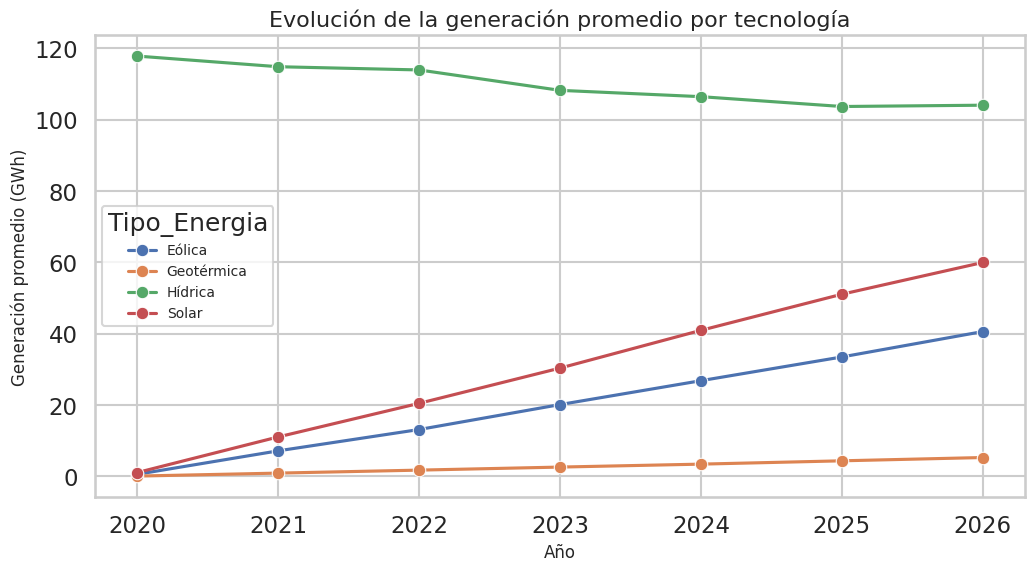

**Interpretación.** La trayectoria sintética sugiere una expansión acelerada de la energía solar y eólica, una entrada gradual pero aún marginal de la geotermia y una reducción relativa de la fuente hídrica. Esto apunta a un patrón de diversificación, aunque la hidroelectricidad conserva una escala dominante durante todo el periodo.

In [7]:
# 1. Tendencia de generación por tecnología
plt.figure()
sns.lineplot(data=df_comparativo, x="Año", y="Generacion_GWh", hue="Tipo_Energia", marker="o")
plt.title("Evolución de la generación promedio por tecnología")
plt.ylabel("Generación promedio (GWh)")
plt.xlabel("Año")
plt.show()

display(Markdown(
    "**Interpretación.** La trayectoria sintética sugiere una expansión acelerada de la energía solar y eólica, "
    "una entrada gradual pero aún marginal de la geotermia y una reducción relativa de la fuente hídrica. "
    "Esto apunta a un patrón de diversificación, aunque la hidroelectricidad conserva una escala dominante durante todo el periodo."
))

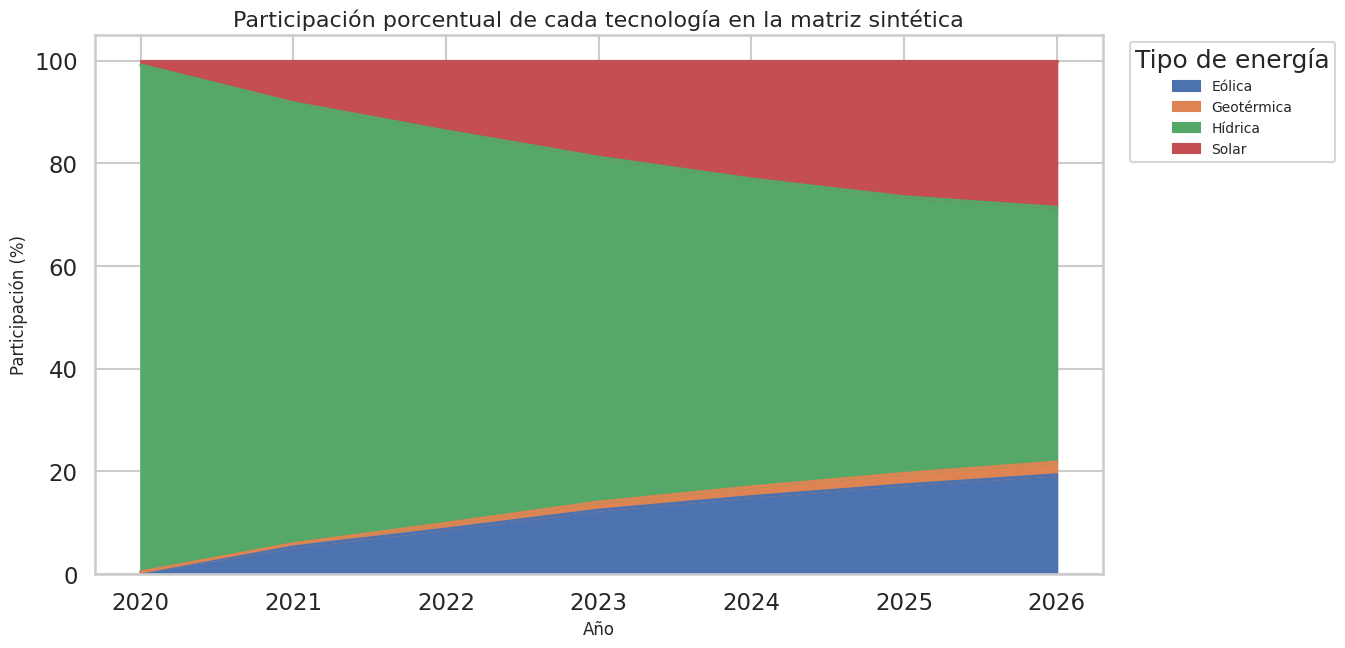

**Interpretación.** El análisis de participación es más revelador que los niveles absolutos: muestra si la expansión de las renovables altera realmente la composición de la matriz. En esta simulación, la participación hídrica cae mientras solar y eólica ganan peso, lo que refleja una transición creíble en términos de composición, no solo de crecimiento aislado.

In [8]:
# 2. Participación en la matriz: área apilada
pivot_part = df_comparativo.pivot(index="Año", columns="Tipo_Energia", values="Participacion_Generacion_pct")
pivot_part.plot(kind="area", stacked=True, figsize=(13, 7))
plt.title("Participación porcentual de cada tecnología en la matriz sintética")
plt.ylabel("Participación (%)")
plt.xlabel("Año")
plt.legend(title="Tipo de energía", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

display(Markdown(
    "**Interpretación.** El análisis de participación es más revelador que los niveles absolutos: muestra si la expansión de las renovables "
    "altera realmente la composición de la matriz. En esta simulación, la participación hídrica cae mientras solar y eólica ganan peso, "
    "lo que refleja una transición creíble en términos de composición, no solo de crecimiento aislado."
))

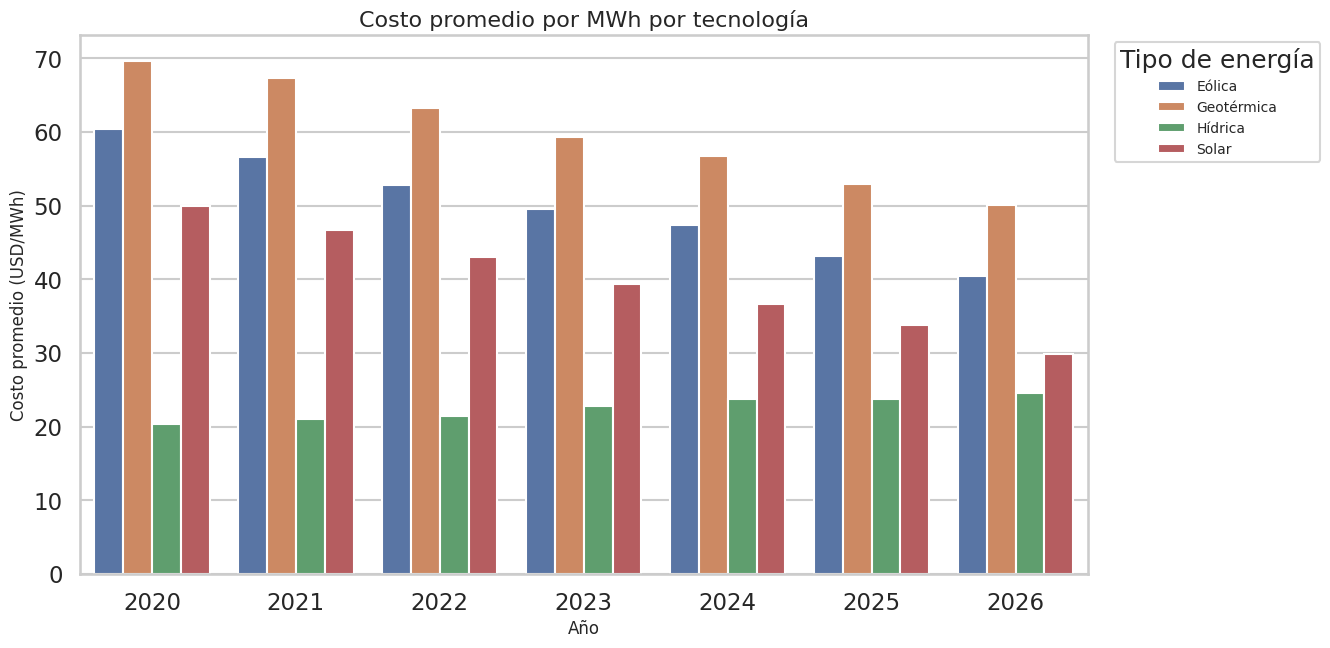

**Interpretación.** La hidroelectricidad se mantiene como la tecnología de menor costo en la simulación, aunque con una ligera tendencia al alza. La solar y la eólica reducen su costo a lo largo del tiempo, mejorando competitividad. La geotermia conserva costos relativamente altos, lo que refuerza su papel como tecnología estratégica de nicho más que como fuente de masificación inmediata.

In [9]:
# 3. Barras comparativas de costo por tecnología y año
plt.figure(figsize=(13, 7))
sns.barplot(data=df_comparativo, x="Año", y="Costo_MWh", hue="Tipo_Energia")
plt.title("Costo promedio por MWh por tecnología")
plt.ylabel("Costo promedio (USD/MWh)")
plt.xlabel("Año")
plt.legend(title="Tipo de energía", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

display(Markdown(
    "**Interpretación.** La hidroelectricidad se mantiene como la tecnología de menor costo en la simulación, aunque con una ligera tendencia al alza. "
    "La solar y la eólica reducen su costo a lo largo del tiempo, mejorando competitividad. La geotermia conserva costos relativamente altos, "
    "lo que refuerza su papel como tecnología estratégica de nicho más que como fuente de masificación inmediata."
))

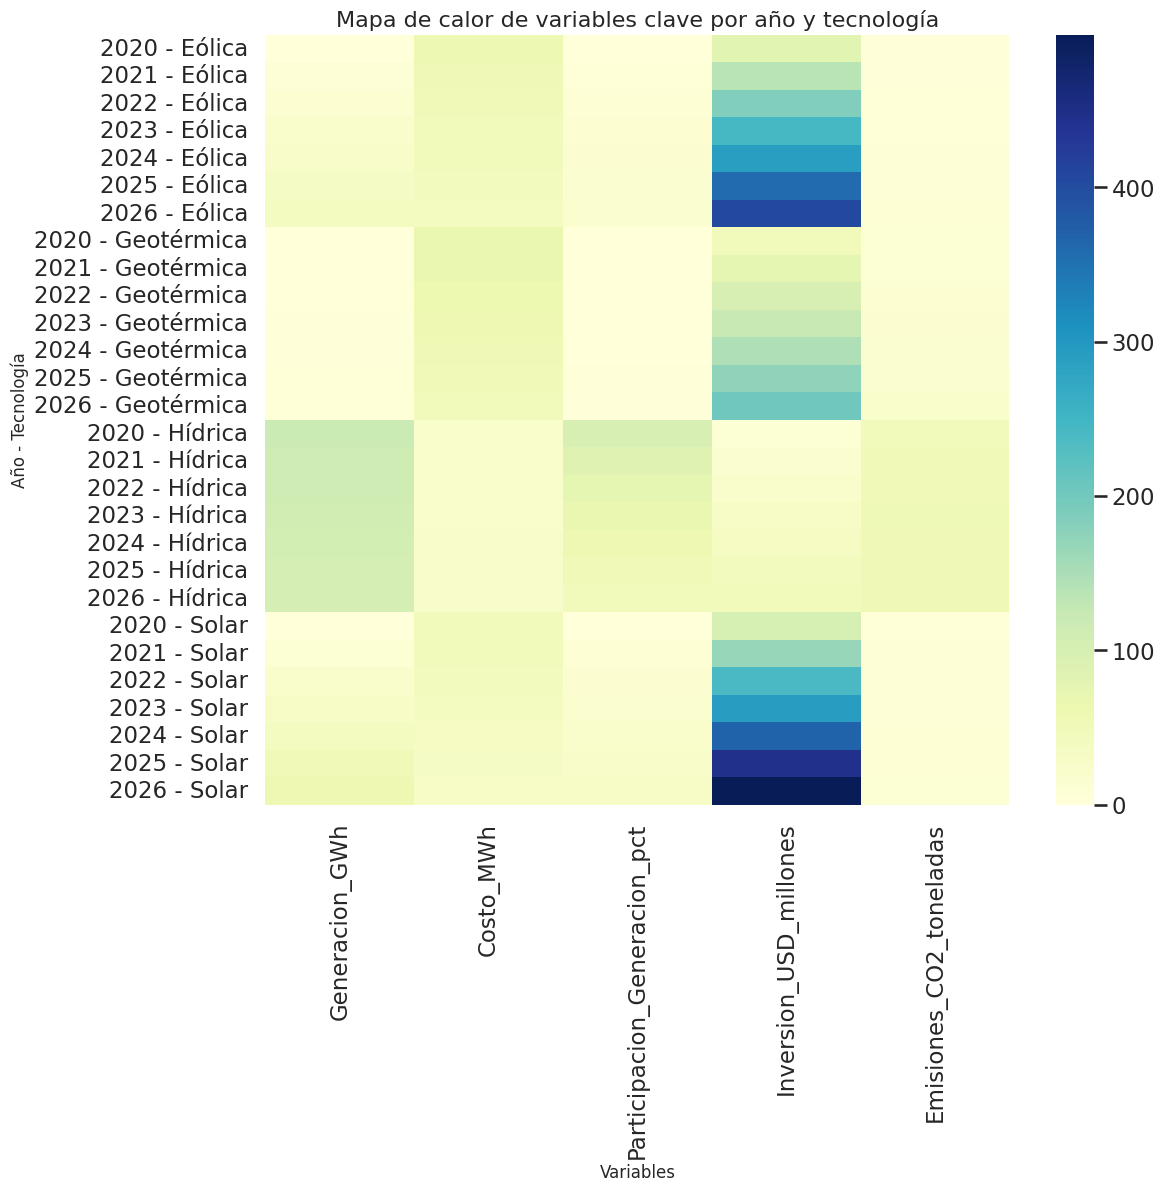

**Interpretación.** El heatmap permite observar simultáneamente escala, costo, inversión y emisiones. La lectura conjunta evidencia que las tecnologías no deben evaluarse con un único criterio: una fuente puede mejorar en generación y costo, pero seguir teniendo una participación baja; otra puede dominar la matriz sin ser la mejor en sostenibilidad relativa.

In [10]:
# 4. Heatmap multivariable por año y tecnología
heatmap_df = df_comparativo.copy()
heatmap_df["Año_Tecnología"] = heatmap_df["Año"].astype(str) + " - " + heatmap_df["Tipo_Energia"]
heatmap_vars = heatmap_df.set_index("Año_Tecnología")[[
    "Generacion_GWh", "Costo_MWh", "Participacion_Generacion_pct",
    "Inversion_USD_millones", "Emisiones_CO2_toneladas"
]]
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_vars, cmap="YlGnBu", annot=False)
plt.title("Mapa de calor de variables clave por año y tecnología")
plt.xlabel("Variables")
plt.ylabel("Año - Tecnología")
plt.show()

display(Markdown(
    "**Interpretación.** El heatmap permite observar simultáneamente escala, costo, inversión y emisiones. "
    "La lectura conjunta evidencia que las tecnologías no deben evaluarse con un único criterio: una fuente puede mejorar en generación y costo, "
    "pero seguir teniendo una participación baja; otra puede dominar la matriz sin ser la mejor en sostenibilidad relativa."
))

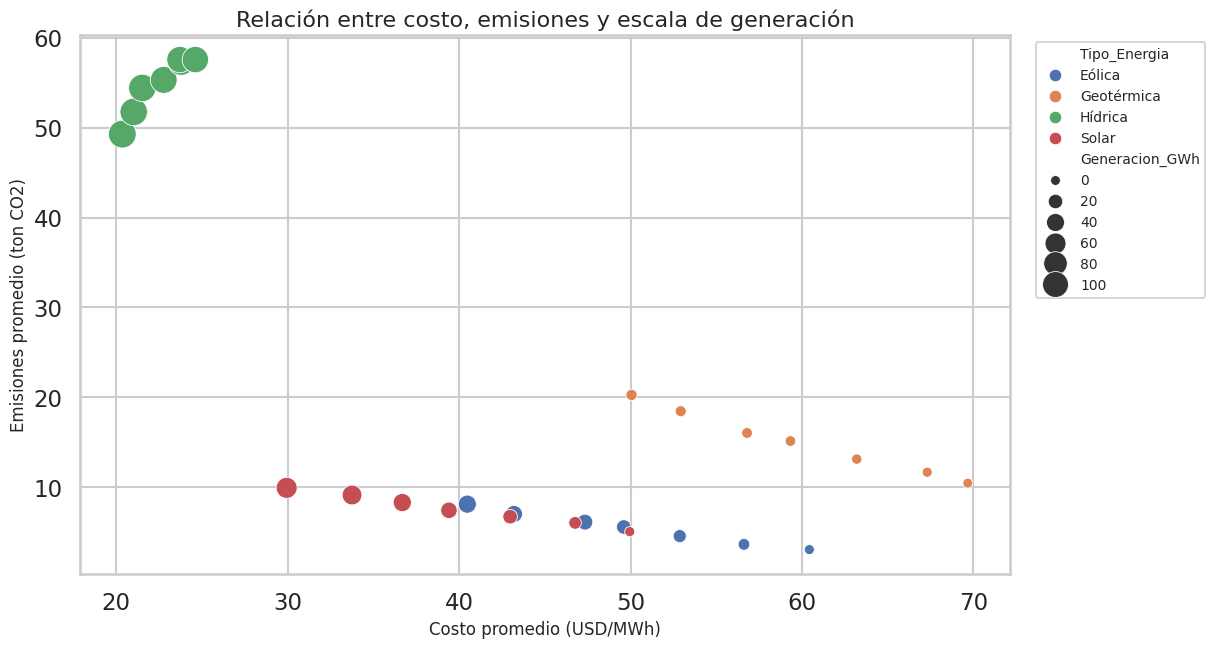

**Interpretación.** El diagrama de dispersión permite identificar trade-offs. La hídrica combina bajo costo con alta escala, pero no necesariamente con la menor intensidad relativa de emisiones en este ejercicio sintético. Solar y eólica se ubican como alternativas de menor impacto absoluto, mientras la geotermia combina baja escala y costo elevado.

In [11]:
# 5. Relación entre costo y emisiones
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_comparativo,
    x="Costo_MWh",
    y="Emisiones_CO2_toneladas",
    hue="Tipo_Energia",
    size="Generacion_GWh",
    sizes=(50, 400)
)
plt.title("Relación entre costo, emisiones y escala de generación")
plt.xlabel("Costo promedio (USD/MWh)")
plt.ylabel("Emisiones promedio (ton CO2)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

display(Markdown(
    "**Interpretación.** El diagrama de dispersión permite identificar trade-offs. "
    "La hídrica combina bajo costo con alta escala, pero no necesariamente con la menor intensidad relativa de emisiones en este ejercicio sintético. "
    "Solar y eólica se ubican como alternativas de menor impacto absoluto, mientras la geotermia combina baja escala y costo elevado."
))

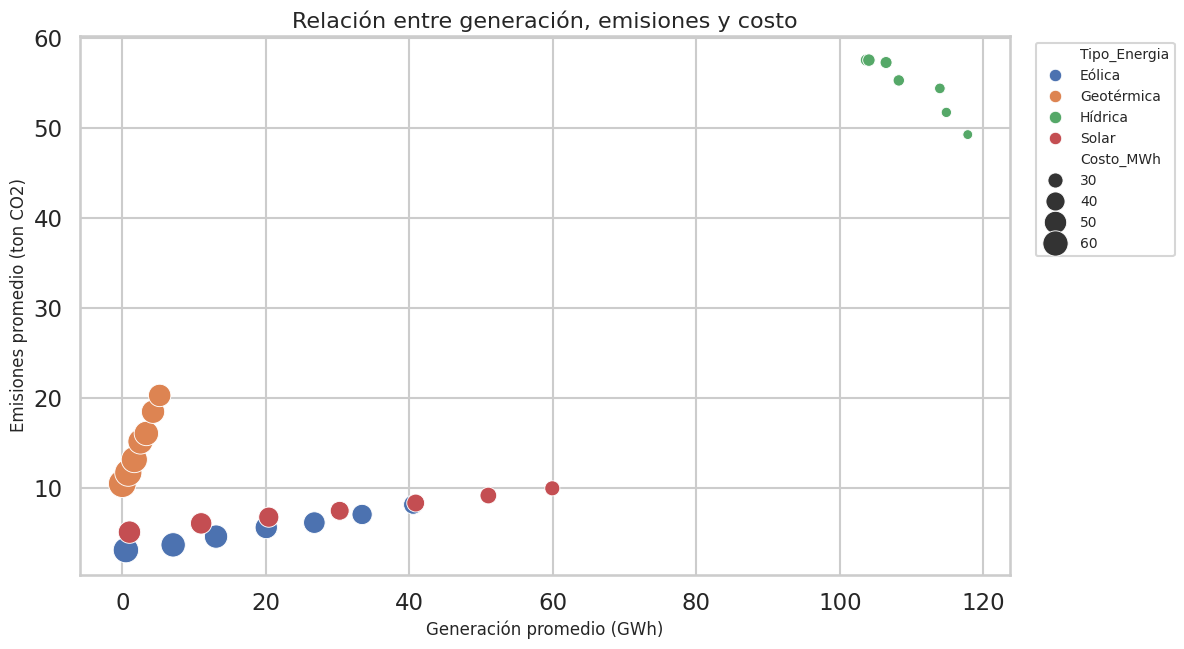

**Interpretación.** La visualización muestra que un mayor volumen de generación no implica automáticamente un mejor desempeño ambiental. Esto es útil para discutir transición energética desde una lógica de portafolio: la matriz óptima suele combinar tecnologías de gran escala con otras de menor huella y creciente competitividad.

In [12]:
# 6. Generación vs emisiones
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_comparativo,
    x="Generacion_GWh",
    y="Emisiones_CO2_toneladas",
    hue="Tipo_Energia",
    size="Costo_MWh",
    sizes=(50, 400)
)
plt.title("Relación entre generación, emisiones y costo")
plt.xlabel("Generación promedio (GWh)")
plt.ylabel("Emisiones promedio (ton CO2)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

display(Markdown(
    "**Interpretación.** La visualización muestra que un mayor volumen de generación no implica automáticamente un mejor desempeño ambiental. "
    "Esto es útil para discutir transición energética desde una lógica de portafolio: la matriz óptima suele combinar tecnologías de gran escala "
    "con otras de menor huella y creciente competitividad."
))

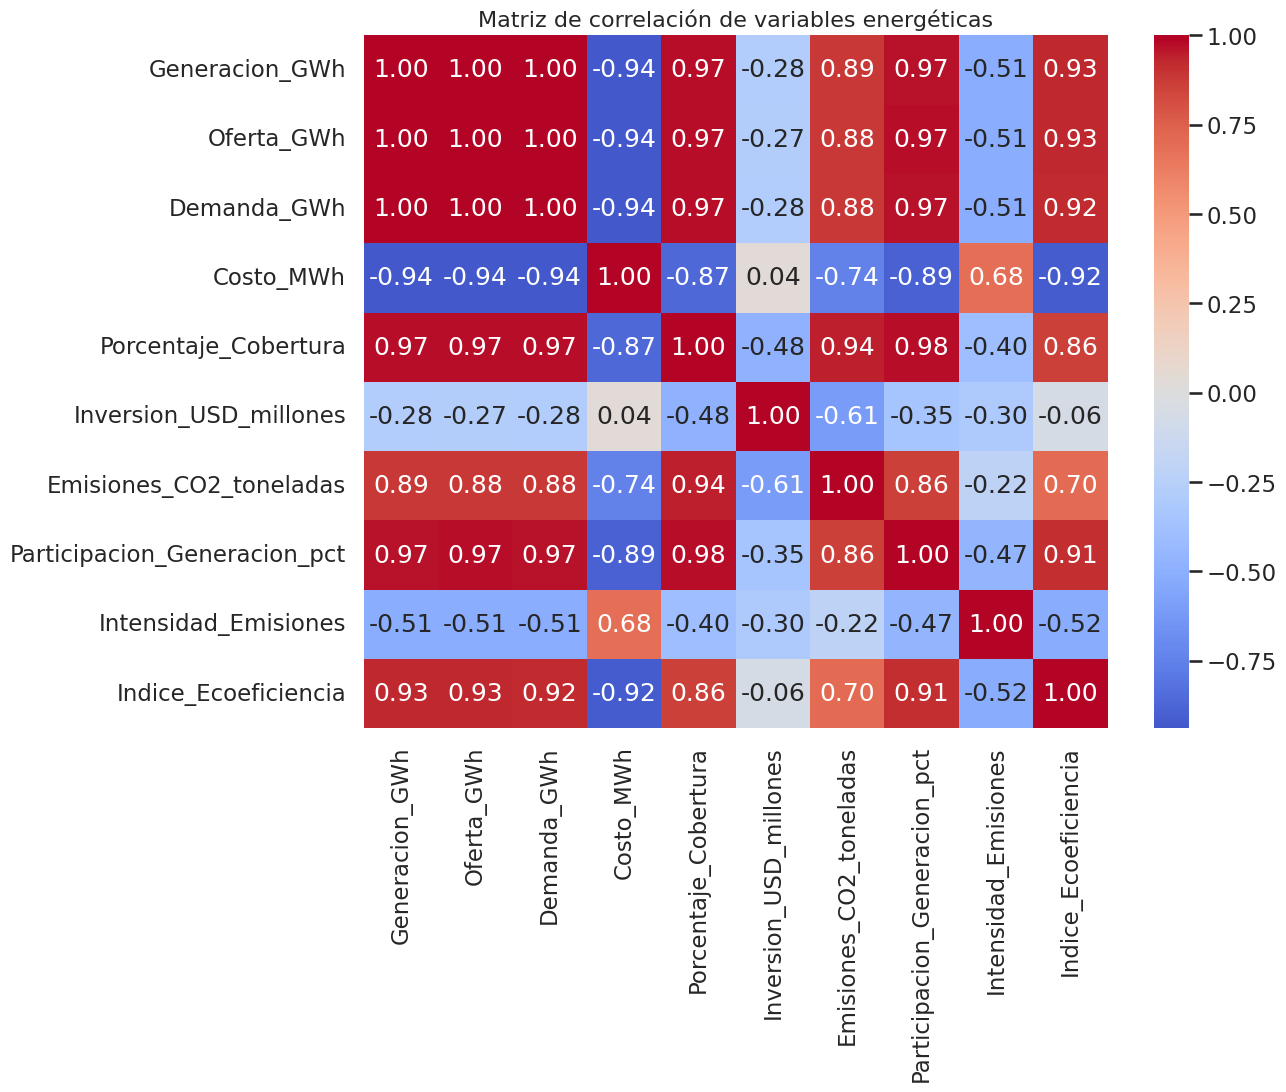

**Interpretación.** La correlación ayuda a distinguir relaciones estructurales del dataset sintético. Por ejemplo, una relación negativa entre costo y generación en algunas tecnologías puede reflejar economías de escala simuladas; una relación positiva entre inversión y generación puede ser consistente con procesos de expansión tecnológica.

In [13]:
# 7. Matriz de correlación
corr_cols = [
    "Generacion_GWh", "Oferta_GWh", "Demanda_GWh", "Costo_MWh",
    "Porcentaje_Cobertura", "Inversion_USD_millones", "Emisiones_CO2_toneladas",
    "Participacion_Generacion_pct", "Intensidad_Emisiones", "Indice_Ecoeficiencia"
]
corr_matrix = df_comparativo[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación de variables energéticas")
plt.show()

display(Markdown(
    "**Interpretación.** La correlación ayuda a distinguir relaciones estructurales del dataset sintético. "
    "Por ejemplo, una relación negativa entre costo y generación en algunas tecnologías puede reflejar economías de escala simuladas; "
    "una relación positiva entre inversión y generación puede ser consistente con procesos de expansión tecnológica."
))

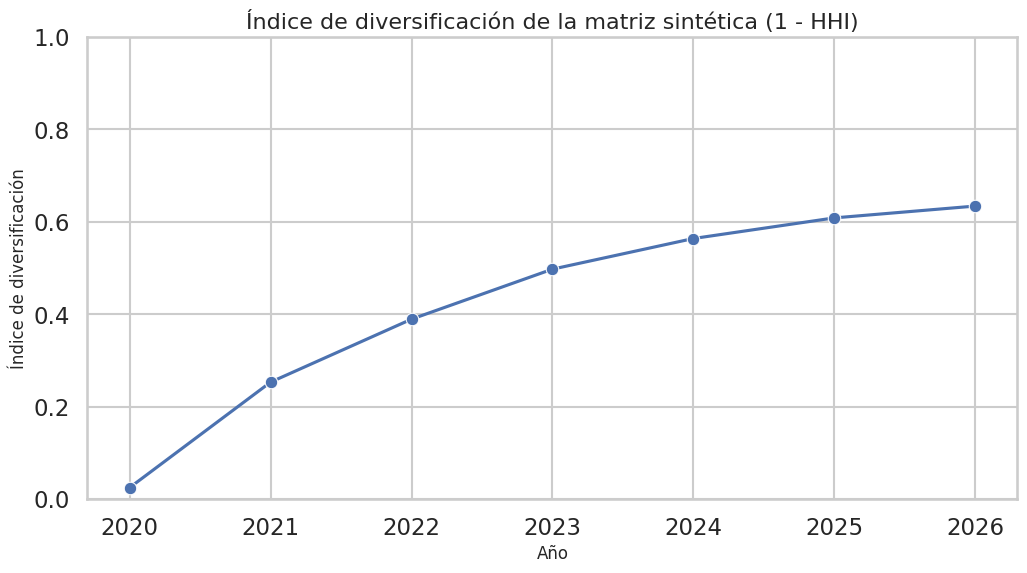

**Interpretación.** Un aumento del índice de diversificación sugiere una matriz menos concentrada en una sola fuente. En una lectura de transición energética, este indicador resume de forma potente el cambio estructural del sistema y complementa el análisis por tecnología individual.

In [14]:
# 8. Evolución del índice de diversificación
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_hhi, x="Año", y="Indice_Diversificacion", marker="o")
plt.title("Índice de diversificación de la matriz sintética (1 - HHI)")
plt.ylabel("Índice de diversificación")
plt.xlabel("Año")
plt.ylim(0, 1)
plt.show()

display(Markdown(
    "**Interpretación.** Un aumento del índice de diversificación sugiere una matriz menos concentrada en una sola fuente. "
    "En una lectura de transición energética, este indicador resume de forma potente el cambio estructural del sistema y complementa el análisis por tecnología individual."
))

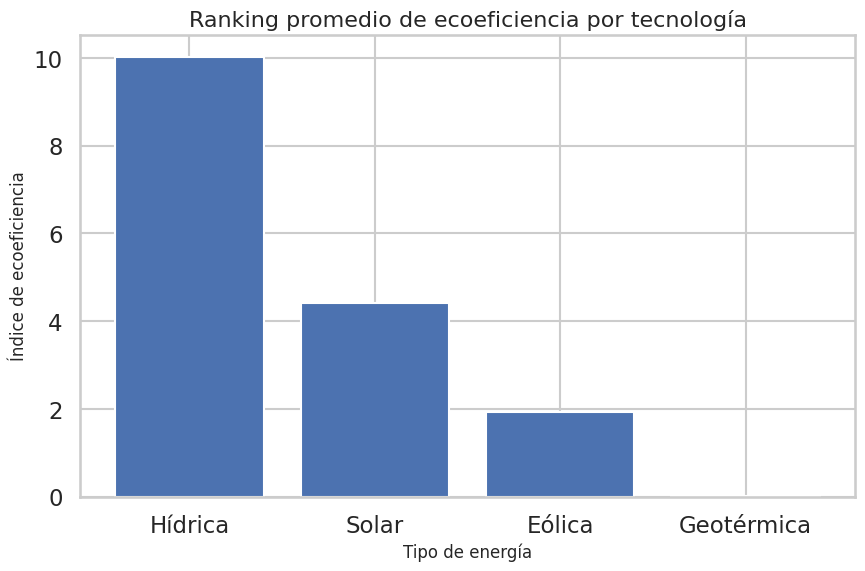

**Interpretación.** Este ranking resume el balance entre generación, costo e intensidad de emisiones. No reemplaza una evaluación técnica exhaustiva, pero sí ofrece una señal sintética útil para comparar tecnologías con criterios múltiples.

In [15]:
# 9. Ranking de ecoeficiencia promedio
ranking_eco = (
    df_comparativo.groupby("Tipo_Energia", as_index=False)["Indice_Ecoeficiencia"]
    .mean()
    .sort_values("Indice_Ecoeficiencia", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(ranking_eco["Tipo_Energia"], ranking_eco["Indice_Ecoeficiencia"])
plt.title("Ranking promedio de ecoeficiencia por tecnología")
plt.ylabel("Índice de ecoeficiencia")
plt.xlabel("Tipo de energía")
plt.show()

display(Markdown(
    "**Interpretación.** Este ranking resume el balance entre generación, costo e intensidad de emisiones. "
    "No reemplaza una evaluación técnica exhaustiva, pero sí ofrece una señal sintética útil para comparar tecnologías con criterios múltiples."
))

## 8. Hallazgos principales

Del análisis comparado emergen cuatro resultados estructurales:

1. **Reducción de concentración tecnológica:** la matriz muestra una menor dependencia relativa de la fuente hídrica y una mayor participación de tecnologías renovables no convencionales.
2. **Consolidación relativa de solar y eólica:** ambas tecnologías mejoran simultáneamente en escala y competitividad, reforzando su papel dentro de la transformación del portafolio energético.
3. **Persistencia de la fuente hídrica como tecnología ancla:** aun con pérdida de participación, la generación hídrica mantiene la mayor escala y un posicionamiento económico favorable.
4. **Geotermia como opción de especialidad estratégica:** su trayectoria es positiva, pero su contribución sigue siendo marginal frente a tecnologías de despliegue más rápido.


In [16]:
# Resumen ejecutivo automatizado
participacion_2020 = (
    df_comparativo[df_comparativo["Año"] == 2020][["Tipo_Energia", "Participacion_Generacion_pct"]]
    .sort_values("Participacion_Generacion_pct", ascending=False)
)
participacion_2026 = (
    df_comparativo[df_comparativo["Año"] == 2026][["Tipo_Energia", "Participacion_Generacion_pct"]]
    .sort_values("Participacion_Generacion_pct", ascending=False)
)

top_eco = ranking_eco.iloc[0]["Tipo_Energia"]
top_growth = df_cagr.sort_values("CAGR_Generacion_pct", ascending=False).iloc[0]["Tipo_Energia"]
div_ini = df_hhi.loc[df_hhi["Año"] == 2020, "Indice_Diversificacion"].iloc[0]
div_fin = df_hhi.loc[df_hhi["Año"] == 2026, "Indice_Diversificacion"].iloc[0]

texto = f"""
### Resumen ejecutivo

- La tecnología con mayor crecimiento relativo de generación en el periodo es **{top_growth}**.
- La mejor posición promedio en el índice simple de ecoeficiencia corresponde a **{top_eco}**.
- El índice de diversificación pasa de **{div_ini:.3f}** en 2020 a **{div_fin:.3f}** en 2026, lo que sugiere una matriz menos concentrada.
- En 2020, la participación dominante corresponde a **{participacion_2020.iloc[0]['Tipo_Energia']}** con **{participacion_2020.iloc[0]['Participacion_Generacion_pct']:.1f}%**.
- En 2026, la fuente líder sigue siendo **{participacion_2026.iloc[0]['Tipo_Energia']}**, pero con una estructura más abierta a otras tecnologías.

Estos resultados deben leerse como un **ejercicio de simulación analítica** y no como una representación observada del sistema eléctrico real.
"""
display(Markdown(texto))


### Resumen ejecutivo

- La tecnología con mayor crecimiento relativo de generación en el periodo es **Eólica**.
- La mejor posición promedio en el índice simple de ecoeficiencia corresponde a **Hídrica**.
- El índice de diversificación pasa de **0.025** en 2020 a **0.634** en 2026, lo que sugiere una matriz menos concentrada.
- En 2020, la participación dominante corresponde a **Hídrica** con **98.7%**.
- En 2026, la fuente líder sigue siendo **Hídrica**, pero con una estructura más abierta a otras tecnologías.

Estos resultados deben leerse como un **ejercicio de simulación analítica** y no como una representación observada del sistema eléctrico real.


## 9. Conclusiones

### Conclusiones técnicas

- La trayectoria observada es consistente con un proceso de **diversificación progresiva**: la matriz reduce concentración en la generación hídrica y amplía la participación de tecnologías alternativas.
- La **energía solar** exhibe la combinación más sólida entre expansión de generación, mejora relativa de costos y reducción de emisiones, lo que la ubica como uno de los vectores más robustos del cambio tecnológico.
- La **energía eólica** también fortalece su posicionamiento competitivo y ambiental, aunque con una escala inferior a la solar dentro del periodo evaluado.
- La **energía hídrica** conserva un rol estructural por volumen y costo relativo; sin embargo, la caída de su participación confirma que el sistema tiende a una configuración menos concentrada.
- La **geotermia** muestra valor estratégico por estabilidad y bajo perfil de emisiones, pero su contribución cuantitativa sigue siendo acotada frente a las demás fuentes analizadas.

### Implicaciones analíticas

1. La transición energética no debe evaluarse únicamente por expansión de nuevas tecnologías, sino por su capacidad de alterar la estructura relativa del sistema.
2. La lectura conjunta de **generación, costo y emisiones** permite identificar tecnologías con mejor balance de desempeño, más allá de su crecimiento absoluto.
3. El avance hacia una matriz más diversificada mejora el perfil de resiliencia del sistema, al reducir dependencia de una sola tecnología dominante.
4. La comparación multivariable sugiere que la competitividad de una tecnología depende de su posición simultánea en escala, economía y sostenibilidad, no de una sola métrica aislada.

### Cierre ejecutivo

El periodo analizado sugiere una trayectoria de transición en la que la expansión de tecnologías renovables no convencionales empieza a modificar la arquitectura de la matriz, aunque sin desplazar todavía el papel estructural de la generación hídrica. En ese contexto, el principal hallazgo no es la sustitución de una fuente por otra, sino la aparición de una **matriz más diversificada, con señales de mayor equilibrio entre crecimiento, competitividad y desempeño ambiental**.


## 10. Extensión metodológica y líneas de profundización

Para una siguiente fase de trabajo, el análisis puede ampliarse en cuatro direcciones:

- incorporación de series observadas de generación y demanda;
- integración de capacidad instalada, disponibilidad y factores de planta;
- inclusión de variables climáticas, hidrológicas y de mercado;
- desarrollo de análisis territorial y escenarios prospectivos.

Estas extensiones permitirían contrastar la dinámica comparada de tecnologías con condiciones operativas reales, señales económicas del sistema y restricciones de expansión. La arquitectura analítica construida en este cuaderno —validación, agregación, ingeniería de variables y lectura multivariable— constituye una base adecuada para escalar hacia ejercicios de mayor resolución técnica y sectorial.
